# Class-conditional conformal prediction with data augmentation: simulation pilot

Class-conditional conformal prediction with data augmentation.

Runs the **pilot**: enough replications to see whether the mechanism produces a
signal, before committing to the full grid.

Design points worth keeping in mind while reading:

- calibration is drawn i.i.d. from the population, so the per-class counts are
  random. The grid is indexed by `E[N_cal,rare] = n_cal * pi_rare`, and the
  realised count is recorded per replication. **Analysis conditions on the
  realised count**, because behaviour is discontinuous around
  `k_y = ceil((n_y+1)(1-alpha)) > n_y`, not gradual.
- two test sets. Per-class metrics come from a balanced one, marginal metrics
  from a population-distributed one. An equal-weight average over classes is a
  macro average, not marginal coverage.
- one scalar `U_i` per observation, shared across candidate labels and across
  transformations, which keeps the APS set nested.

## 1. Setup

In [ ]:
# Option A — files uploaded straight into the session
CODE_DIR = "/content"

# Option B — files in Drive (recommended: results survive a disconnect)
from google.colab import drive
drive.mount("/content/drive")

#CODE_DIR = "/content/drive/MyDrive/Conformal_Prediction_Research/Class_Conditional_CP_with_Data_Augmentation/csda_revision/code"
#RESULTS_DIR = "/content/results_new"
#RESULTS_DIR = "/content/drive/MyDrive/Conformal_Prediction_Research/Class_Conditional_CP_with_Data_Augmentation/csda_revision/results_new"

BASE        = "/content/drive/MyDrive/Conformal_Prediction_Research/Class_Conditional_CP_with_Data_Augmentation/csda_revision/"
CODE_DIR    = f"{BASE}/code"
RESULTS_DIR = f"{BASE}/results_R300"     # results MUST live on Drive


import sys, os
sys.path.insert(0, CODE_DIR)
os.makedirs(RESULTS_DIR, exist_ok=True)


print("code   :", CODE_DIR)
print("results:", RESULTS_DIR)
print("files  :", sorted(f for f in os.listdir(CODE_DIR) if f.endswith(".py")))

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
code   : /content/drive/MyDrive/Conformal_Prediction_Research/Class_Conditional_CP_with_Data_Augmentation/csda_revision//code
results: /content/drive/MyDrive/Conformal_Prediction_Research/Class_Conditional_CP_with_Data_Augmentation/csda_revision//results_R300
files  : ['calibration.py', 'clustering_utils.py', 'ding_conformal_utils.py', 'groups.py', 'metrics.py', 'run_grid.py', 'scores.py', 'simulate.py']


In [ ]:
# torch is NOT needed: the vendored reference implementation has it commented out.
!pip install -q xgboost pyarrow 2>/dev/null | tail -1
import numpy, pandas, sklearn, scipy
print("numpy", numpy.__version__, "| pandas", pandas.__version__,
      "| sklearn", sklearn.__version__, "| scipy", scipy.__version__)

numpy 2.0.2 | pandas 2.2.2 | sklearn 1.6.1 | scipy 1.16.3


## 2. Sanity checks

These must pass before any result is worth reading. `simulate` also runs
per-replication assertions when `strict=True`, which is the default.

In [ ]:
import numpy as np
from scores import aps_scores, draw_uniform
from groups import SignFlipGroup, make_nuisance_block

rng = np.random.default_rng(0)

# deterministic APS follows the reference implementation
def reference_aps_deterministic(smx):
    pi = np.argsort(-smx, axis=1, kind="stable")
    s  = np.take_along_axis(smx, pi, axis=1)
    return np.take_along_axis(np.cumsum(s, axis=1),
                              np.argsort(pi, axis=1, kind="stable"), axis=1) - smx

smx = rng.random((300, 8)); smx /= smx.sum(1, keepdims=True)
print("deterministic APS matches reference:",
      np.allclose(reference_aps_deterministic(smx), aps_scores(smx, None)))

U = draw_uniform(300, 8, rng)
print("one scalar U per observation       :", bool(np.all(U == U[:, :1])))

g = SignFlipGroup(n_features=10, n_nuisance=6)
X = np.hstack([rng.normal(size=(200, 4)), make_nuisance_block(200, 6, rng)])
Xg = g.apply(X, g.sample(1, rng)[0])
print("base block untouched               :", np.allclose(X[:, :4], Xg[:, :4]))
print("nuisance flipped only              :", np.allclose(np.abs(X[:, 4:]), np.abs(Xg[:, 4:])))

rc, rt = (np.random.default_rng(s) for s in np.random.SeedSequence(1).spawn(2))
print("cal/test U independent streams     :",
      not np.allclose(draw_uniform(30, 5, rc), draw_uniform(80, 5, rt)[:30]))

deterministic APS matches reference: True
one scalar U per observation       : True
base block untouched               : True
nuisance flipped only              : True
cal/test U independent streams     : True


## 3. Cost of one replication\n\nRun this before anything long.

In [ ]:
import time
from simulate import SimConfig, run_replication, _population_size

cfg = SimConfig(scenario="s3_nuisance", model="XGBoost",
                n_informative=5, n_nuisance=20, class_sep=0.8, balanced=False,
                n_cal=500, n_train=4000,
                n_test_pop=2000, n_test_balanced_per_class=500,
                n_transforms=16, n_reps=1, outdir=RESULTS_DIR)

print("E[N_cal,rare] :", cfg.expected_rare_cal())
print("population    :", _population_size(cfg), "observations")

t = time.time(); rows = run_replication(cfg, rep=0); dt = time.time() - t
print(f"\none replication: {dt:.1f}s -> {len(rows)} rows")
print(f"R=200 for this cell         : {dt*200/60:.0f} min")
print(f"whole grid (34 cells, R=200): {dt*200*34/3600:.1f} h single-process")

E[N_cal,rare] : 20.0
population    : 38000 observations

one replication: 14.0s -> 128 rows
R=200 for this cell         : 47 min
whole grid (34 cells, R=200): 26.5 h single-process


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


## 4. Choosing B

`B` does not enter the coverage guarantee and does not increase the effective
calibration size: it only controls the Monte Carlo error of the orbit average.
Pick the value beyond which the metrics stop moving and keep it fixed.
`B = 1` is the control: one random transformation, no averaging.

In [ ]:
from dataclasses import replace
import pandas as pd, numpy as np, metrics as M
from simulate import run_replication

frames = []
#for B in [1, 4, 16, 64]:
for B in [16]:
    c = replace(cfg, n_transforms=B, n_reps=30)
    frames.append(pd.DataFrame(sum((run_replication(c, r) for r in range(c.n_reps)), [])))
repB = M.per_replication(pd.concat(frames))

Btab = M.summarize(repB, by=["method", "n_transforms"])
display(Btab[Btab.method.str.contains("orbitavg|ttaavg")]
        [["method", "n_transforms", "WCU", "AvgSize"]]
        .round(3).sort_values(["method", "n_transforms"]))

d = M.paired_delta(repB[(repB.n_transforms == 16) & (~repB.train_aug)],
                   "AvgSize", "classwise_ttaavg", "classwise_orbitavg")
d["t"] = d.mean_delta / d.mcse
display(d[["mean_delta", "mcse", "t", "frac_negative", "n"]].round(4))

,method,n_transforms,WCU,AvgSize
0,classwise_orbitavg,16,0.057,2.097
2,classwise_ttaavg,16,0.055,2.112
4,marginal_orbitavg,16,0.217,1.543
6,marginal_ttaavg,16,0.221,1.549


,mean_delta,mcse,t,frac_negative,n
0,-0.0118,0.0116,-1.0124,0.6,30


## 4b. Locate the empty-slice warnings

The pilot emits `RuntimeWarning: Mean of empty slice` in some replications. The
expected source is clustered conformal: when the rare classes hold at most
1/alpha - 1 points they cannot be assigned to a cluster, a cluster ends up
empty, and the mean of an empty array is taken.

That is worth confirming rather than assuming, because the same warning would
also appear if one of our own arrays were empty, and the two cases call for
opposite responses: the first is expected behaviour to be suppressed at the
wrapper, the second is a bug.

Turning the warning into an error locates the exact line.

In [ ]:
import warnings, traceback
from dataclasses import replace
from simulate import run_replication

warnings.filterwarnings("error", message=".*[Mm]ean of empty slice.*",
                        category=RuntimeWarning)

c_low = replace(cfg, n_cal=125, n_reps=1, strict=True)   # the low-data regime
found = False
for r in range(10):
    try:
        run_replication(c_low, r)
    except RuntimeWarning:
        print(f"--- warning raised in replication {r}\n")
        traceback.print_exc()
        found = True
        break
if not found:
    print("no warning in 10 replications at n_cal=125")

warnings.resetwarnings()   # do not leave warnings as errors for the rest of the session

print("\nIf the last frame of our code is in ding_conformal_utils.py or "
      "clustering_utils.py, this is the expected degeneracy of clustered "
      "conformal and calibration._silent already suppresses it.\n"
      "If it points at simulate.py, scores.py or metrics.py, it is a bug.")

no warning in 10 replications at n_cal=125

If the last frame of our code is in ding_conformal_utils.py or clustering_utils.py, this is the expected degeneracy of clustered conformal and calibration._silent already suppresses it.
If it points at simulate.py, scores.py or metrics.py, it is a bug.


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


## 5. Pilot

One scenario, one model, the full calibration-size axis. `n_cal` is chosen so
that `E[N_cal,rare]` lands on 5, 10, 20, 50, 100, 200.

In [ ]:
from simulate import run

NCAL = [125, 250, 500, 1250, 2500, 5000]   # -> E[N_rare] = 5,10,20,50,100,200
R_PILOT = 30
B = 16                                      # from section 4

for n in NCAL:
    c = replace(cfg, n_cal=n, n_transforms=B, n_reps=R_PILOT, run_train_aug=True)
    print(f"--- n_cal={n}  E[N_rare]={c.expected_rare_cal():.0f}")
    run(c, verbose=True)

--- n_cal=125  E[N_rare]=5
[s3_nuisance_XGBoost_ncal00125_a01_B16_exact] 5/30
[s3_nuisance_XGBoost_ncal00125_a01_B16_exact] 10/30
[s3_nuisance_XGBoost_ncal00125_a01_B16_exact] 15/30
[s3_nuisance_XGBoost_ncal00125_a01_B16_exact] 20/30
[s3_nuisance_XGBoost_ncal00125_a01_B16_exact] 25/30
[s3_nuisance_XGBoost_ncal00125_a01_B16_exact] 30/30
--- n_cal=250  E[N_rare]=10
[s3_nuisance_XGBoost_ncal00250_a01_B16_exact] 5/30
[s3_nuisance_XGBoost_ncal00250_a01_B16_exact] 10/30


/usr/local/lib/python3.12/dist-packages/numpy/_core/fromnumeric.py:3596: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/usr/local/lib/python3.12/dist-packages/numpy/_core/_methods.py:138: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


[s3_nuisance_XGBoost_ncal00250_a01_B16_exact] 15/30
[s3_nuisance_XGBoost_ncal00250_a01_B16_exact] 20/30
[s3_nuisance_XGBoost_ncal00250_a01_B16_exact] 25/30
[s3_nuisance_XGBoost_ncal00250_a01_B16_exact] 30/30
--- n_cal=500  E[N_rare]=20
[s3_nuisance_XGBoost_ncal00500_a01_B16_exact] 5/30
[s3_nuisance_XGBoost_ncal00500_a01_B16_exact] 10/30
[s3_nuisance_XGBoost_ncal00500_a01_B16_exact] 15/30
[s3_nuisance_XGBoost_ncal00500_a01_B16_exact] 20/30
[s3_nuisance_XGBoost_ncal00500_a01_B16_exact] 25/30
[s3_nuisance_XGBoost_ncal00500_a01_B16_exact] 30/30
--- n_cal=1250  E[N_rare]=50
[s3_nuisance_XGBoost_ncal01250_a01_B16_exact] 5/30


/usr/local/lib/python3.12/dist-packages/numpy/_core/fromnumeric.py:3596: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/usr/local/lib/python3.12/dist-packages/numpy/_core/_methods.py:138: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/usr/local/lib/python3.12/dist-packages/numpy/_core/fromnumeric.py:3596: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/usr/local/lib/python3.12/dist-packages/numpy/_core/_methods.py:138: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/usr/local/lib/python3.12/dist-packages/numpy/_core/fromnumeric.py:3596: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/usr/local/lib/python3.12/dist-packages/numpy/_core/_methods.py:138: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/usr/local/lib/python3

[s3_nuisance_XGBoost_ncal01250_a01_B16_exact] 10/30
[s3_nuisance_XGBoost_ncal01250_a01_B16_exact] 15/30
[s3_nuisance_XGBoost_ncal01250_a01_B16_exact] 20/30
[s3_nuisance_XGBoost_ncal01250_a01_B16_exact] 25/30
[s3_nuisance_XGBoost_ncal01250_a01_B16_exact] 30/30
--- n_cal=2500  E[N_rare]=100
[s3_nuisance_XGBoost_ncal02500_a01_B16_exact] 5/30
[s3_nuisance_XGBoost_ncal02500_a01_B16_exact] 10/30
[s3_nuisance_XGBoost_ncal02500_a01_B16_exact] 15/30
[s3_nuisance_XGBoost_ncal02500_a01_B16_exact] 20/30
[s3_nuisance_XGBoost_ncal02500_a01_B16_exact] 25/30
[s3_nuisance_XGBoost_ncal02500_a01_B16_exact] 30/30
--- n_cal=5000  E[N_rare]=200
[s3_nuisance_XGBoost_ncal05000_a01_B16_exact] 5/30
[s3_nuisance_XGBoost_ncal05000_a01_B16_exact] 10/30
[s3_nuisance_XGBoost_ncal05000_a01_B16_exact] 15/30
[s3_nuisance_XGBoost_ncal05000_a01_B16_exact] 20/30
[s3_nuisance_XGBoost_ncal05000_a01_B16_exact] 25/30
[s3_nuisance_XGBoost_ncal05000_a01_B16_exact] 30/30


## 6. Reading the results

Note the two size columns. `AvgSize` is population-weighted, from the
population test set; `MacroSize` weights classes equally, from the balanced
one. They answer different questions and should not be mixed.

In [ ]:
import metrics as M

df   = M.load(RESULTS_DIR)
rep  = M.per_replication(df)
summ = M.summarize(rep)
print(f"{len(df)} long rows -> {len(rep)} replication rows -> {len(summ)} cells")

view = summ[~summ.train_aug]
display(view[["n_cal","method","guarantee","MCCD","WCU","WCU_mcse",
              "AvgSize","MacroSize","CovMarginal","n_infinite_qhat","n_rep"]]
        .round(3).sort_values(["n_cal","WCU"]))

23040 long rows -> 2880 replication rows -> 96 cells


,n_cal,method,guarantee,MCCD,WCU,WCU_mcse,AvgSize,MacroSize,CovMarginal,n_infinite_qhat,n_rep
1,125,classwise_plain,class-conditional,0.075,0.065,0.013,5.115,5.148,0.938,3.567,30
0,125,classwise_orbitavg,class-conditional,0.074,0.069,0.013,5.032,5.073,0.940,3.567,30
2,125,classwise_ttaavg,class-conditional,0.075,0.070,0.013,5.059,5.093,0.940,3.567,30
7,125,naive_multicopy,none,0.064,0.172,0.020,2.159,2.471,0.896,0.000,30
6,125,marginal_ttaavg,marginal,0.071,0.173,0.011,1.742,2.042,0.915,0.000,30
4,125,marginal_orbitavg,marginal,0.073,0.175,0.012,1.716,2.015,0.913,0.000,30
3,125,clustered,cluster-conditional,0.079,0.195,0.010,1.757,2.045,0.913,0.000,30
5,125,marginal_plain,marginal,0.079,0.195,0.010,1.757,2.045,0.913,0.000,30
16,250,classwise_orbitavg,class-conditional,0.054,0.085,0.012,2.487,2.822,0.912,0.267,30
18,250,classwise_ttaavg,class-conditional,0.054,0.085,0.012,2.519,2.842,0.912,0.267,30


### The regime boundary

Below roughly `n_y = 1/alpha` no finite classwise quantile exists: the
threshold is infinite, the label enters every set, and coverage is one by
construction. That is not noise to be averaged away, it is the result — it says
where classwise calibration stops being usable, which is half the practical
rule the paper has to deliver.

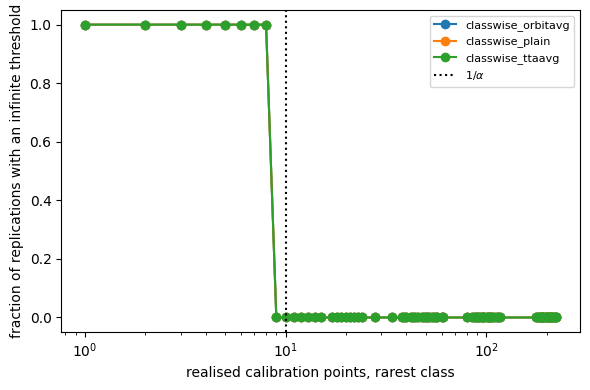

In [ ]:
import matplotlib.pyplot as plt

inf_rate = (df[df.method.str.startswith("classwise") & ~df.train_aug]
              .groupby(["method", "n_cal_realized_rarest"])["n_infinite_qhat"]
              .apply(lambda s: float((s > 0).mean())).reset_index(name="frac_infinite"))

fig, ax = plt.subplots(figsize=(6, 4))
for m, sub in inf_rate.groupby("method"):
    sub = sub.sort_values("n_cal_realized_rarest")
    ax.plot(sub.n_cal_realized_rarest, sub.frac_infinite, "o-", label=m)
ax.axvline(1 / cfg.alpha, color="k", ls=":", label=r"$1/\alpha$")
ax.set_xscale("log"); ax.set_xlabel("realised calibration points, rarest class")
ax.set_ylabel("fraction of replications with an infinite threshold")
ax.legend(fontsize=8); plt.tight_layout(); plt.show()

### The 2 x 2 ablation

Rows are calibration arms, columns are training augmentation. The four corners
are the referees' 2 x 2; the extra rows separate the two aggregation points,
which the 2 x 2 alone conflates. The two arms share a model seed, so the
difference is attributable to the augmentation rather than to a different
random initialisation.

In [ ]:
display(M.ablation_table(rep, metric="WCU").round(3))

,scenario,model,alpha,n_cal,method,train_aug=False,train_aug=True,delta
0,s3_nuisance,XGBoost,0.1,125,classwise_orbitavg,0.069,0.072,0.003
1,s3_nuisance,XGBoost,0.1,125,classwise_plain,0.065,0.074,0.009
2,s3_nuisance,XGBoost,0.1,125,classwise_ttaavg,0.070,0.071,0.002
3,s3_nuisance,XGBoost,0.1,125,clustered,0.195,0.192,-0.003
4,s3_nuisance,XGBoost,0.1,125,marginal_orbitavg,0.175,0.178,0.003
5,s3_nuisance,XGBoost,0.1,125,marginal_plain,0.195,0.192,-0.003
6,s3_nuisance,XGBoost,0.1,125,marginal_ttaavg,0.173,0.178,0.005
7,s3_nuisance,XGBoost,0.1,125,naive_multicopy,0.172,0.190,0.017
8,s3_nuisance,XGBoost,0.1,250,classwise_orbitavg,0.085,0.074,-0.011
9,s3_nuisance,XGBoost,0.1,250,classwise_plain,0.089,0.073,-0.016


In [ ]:
display(M.ablation_table(rep, metric="AvgSize").round(3))

,scenario,model,alpha,n_cal,method,train_aug=False,train_aug=True,delta
0,s3_nuisance,XGBoost,0.1,125,classwise_orbitavg,5.032,4.989,-0.043
1,s3_nuisance,XGBoost,0.1,125,classwise_plain,5.115,5.042,-0.073
2,s3_nuisance,XGBoost,0.1,125,classwise_ttaavg,5.059,5.008,-0.051
3,s3_nuisance,XGBoost,0.1,125,clustered,1.757,1.628,-0.129
4,s3_nuisance,XGBoost,0.1,125,marginal_orbitavg,1.716,1.612,-0.104
5,s3_nuisance,XGBoost,0.1,125,marginal_plain,1.757,1.628,-0.129
6,s3_nuisance,XGBoost,0.1,125,marginal_ttaavg,1.742,1.627,-0.115
7,s3_nuisance,XGBoost,0.1,125,naive_multicopy,2.159,1.959,-0.200
8,s3_nuisance,XGBoost,0.1,250,classwise_orbitavg,2.487,2.417,-0.071
9,s3_nuisance,XGBoost,0.1,250,classwise_plain,2.638,2.564,-0.074


In [ ]:
display(M.ablation_table(rep, metric="MacroSize").round(3))

,scenario,model,alpha,n_cal,method,train_aug=False,train_aug=True,delta
0,s3_nuisance,XGBoost,0.1,125,classwise_orbitavg,5.073,4.990,-0.083
1,s3_nuisance,XGBoost,0.1,125,classwise_plain,5.148,5.040,-0.108
2,s3_nuisance,XGBoost,0.1,125,classwise_ttaavg,5.093,5.005,-0.088
3,s3_nuisance,XGBoost,0.1,125,clustered,2.045,1.864,-0.181
4,s3_nuisance,XGBoost,0.1,125,marginal_orbitavg,2.015,1.857,-0.158
5,s3_nuisance,XGBoost,0.1,125,marginal_plain,2.045,1.864,-0.181
6,s3_nuisance,XGBoost,0.1,125,marginal_ttaavg,2.042,1.870,-0.172
7,s3_nuisance,XGBoost,0.1,125,naive_multicopy,2.471,2.221,-0.250
8,s3_nuisance,XGBoost,0.1,250,classwise_orbitavg,2.822,2.706,-0.116
9,s3_nuisance,XGBoost,0.1,250,classwise_plain,2.945,2.835,-0.111


### Mechanism

`var_within_orbit` estimates `Var_g[S(gX,Y)]`, the quantity governing the
variance reduction. Where it is near zero the theory predicts no gain, so a
null result there confirms the account rather than contradicting it.

In [ ]:
display(M.mechanism_table(rep).round(4))

,scenario,model,n_cal,n_transforms,exact_invariance,train_aug,var_within_orbit,rank_plain,rank_ttaavg,macro_f1,rank_delta
0,s3_nuisance,XGBoost,125,16,True,False,0.0139,1.6344,1.5932,0.6453,-0.0411
1,s3_nuisance,XGBoost,125,16,True,True,0.0093,1.5716,1.5519,0.6705,-0.0197
2,s3_nuisance,XGBoost,250,16,True,False,0.0138,1.6269,1.5811,0.6468,-0.0458
3,s3_nuisance,XGBoost,250,16,True,True,0.0091,1.5589,1.5401,0.6735,-0.0188
4,s3_nuisance,XGBoost,500,16,True,False,0.0135,1.6174,1.5745,0.6446,-0.0430
5,s3_nuisance,XGBoost,500,16,True,True,0.0089,1.5536,1.5351,0.6738,-0.0184
6,s3_nuisance,XGBoost,1250,16,True,False,0.0136,1.6197,1.5789,0.6508,-0.0408
7,s3_nuisance,XGBoost,1250,16,True,True,0.0089,1.5528,1.5327,0.6779,-0.0201
8,s3_nuisance,XGBoost,2500,16,True,False,0.0136,1.6263,1.5850,0.6423,-0.0413
9,s3_nuisance,XGBoost,2500,16,True,True,0.0091,1.5689,1.5492,0.6676,-0.0197


### The distribution-free ceiling

Class-conditional coverage conditional on the calibration set follows
`Beta(k_y, n_y + 1 - k_y)`, a law depending only on `n_y` and `alpha` and
invariant to the score. No score transformation can beat it.

The comparison is made **class by class and conditional on the realised n_y**,
and the reference is inflated by the binomial noise of the finite test set:

    Var(Chat_y) = Var(C_y) + E[C_y(1-C_y)] / m_y.

In [ ]:
spread = M.rare_class_spread(df[~df.train_aug], alpha=cfg.alpha, min_reps=10)
display(spread.round(4))

if spread.empty:
    print("No bin has enough replications for a usable spread estimate. "
          "Lower min_reps, widen the bins, or increase R.")
else:
    fig, ax = plt.subplots(figsize=(6, 4))
    ok = spread[~spread.degenerate]
    for m, sub in ok.groupby("method"):
        sub = sub.sort_values("n_cal_cls")
        ax.plot(sub.n_cal_cls, sub.observed_sd, "o-", label=m)
    ref = ok.drop_duplicates("n_cal_cls").sort_values("n_cal_cls")
    ax.plot(ref.n_cal_cls, ref.sd_observable, "k--", label="Beta + binomial (floor)")
    ax.set_xscale("log")
    ax.set_xlabel("realised calibration points, rarest class")
    ax.set_ylabel("sd of class-conditional coverage")
    ax.set_title("Observed spread against the distribution-free floor")
    ax.legend(fontsize=8); plt.tight_layout(); plt.show()

### Coverage / efficiency trade-off

A Pareto front rather than a single weighted index: a scalar combination of a
percentage and a label count needs a weight with no natural value, and it ranks
together methods pursuing different guarantees.

In [ ]:
front = M.pareto_front(view[view.n_cal == 500])
display(front[["method","guarantee","WCU","AvgSize","on_front"]]
        .round(3).sort_values("WCU"))

,method,guarantee,WCU,AvgSize,on_front
33,classwise_plain,class-conditional,0.053,2.299,True
32,classwise_orbitavg,class-conditional,0.056,2.158,True
34,classwise_ttaavg,class-conditional,0.056,2.186,False
39,naive_multicopy,none,0.072,2.027,True
36,marginal_orbitavg,marginal,0.225,1.574,True
38,marginal_ttaavg,marginal,0.229,1.576,False
35,clustered,cluster-conditional,0.239,1.627,False
37,marginal_plain,marginal,0.240,1.625,False


## 7. How many replications

`MCSE = sd / sqrt(R)`. To halve it, quadruple `R`. Pick `R` so the SE is small
relative to the differences you intend to claim.

In [ ]:
import numpy as np, pandas as pd
target = 0.005
sd = rep[~rep.train_aug].groupby("method")["WCU"].std(ddof=1)
need = np.ceil((sd / target) ** 2).astype(int)
display(pd.DataFrame({"sd_across_reps": sd.round(4),
                      f"R for SE<={target}": need}).sort_values("sd_across_reps"))

,sd_across_reps,R for SE<=0.005
method,,
classwise_plain,0.0497,99
classwise_ttaavg,0.0501,101
classwise_orbitavg,0.0511,105
marginal_plain,0.0676,183
marginal_orbitavg,0.0685,188
marginal_ttaavg,0.0688,190
clustered,0.0750,225
naive_multicopy,0.0783,246
